In [1]:
# import pandas for data manipulation and analysis
import pandas as pd

# import NumPy for numerical operations
import numpy as np

# import Matplotlib for creating visualizations
import matplotlib.pyplot as plt

# import Seaborn for statistical data visualization
import seaborn as sns

In [2]:
# load the dataset from the CSV file
df = pd.read_csv('data.csv')

In [3]:
# display the first five rows of the dataset
df.head()

,feature1,feature2,feature3,target
0,-0.570563,1.420342,0.495580,-9.763182
1,-0.990563,0.556965,1.045064,-24.029355
2,-0.674728,0.150617,1.774645,45.616421
3,0.388250,-0.387127,-0.110229,34.135737
4,1.167882,-0.024104,0.145063,86.663647


In [4]:
# select the first three columns as input features
X = df.iloc[:, 0:3].values

# select the last column as the target variable
y = df.iloc[:, -1].values

In [5]:
# import the function used to split the data into training and testing sets
from sklearn.model_selection import train_test_split

# split the data into 70% training and 30% testing sets
# random_state=1 ensures the same split every time
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=1
)

In [6]:
# import the linear regression model
from sklearn.linear_model import LinearRegression

# create a linear regression model
model = LinearRegression()

# train the model using the training data
model.fit(X_train, y_train)

LinearRegression()

In [7]:
# make predictions on the test data
y_pred = model.predict(X_test)

# calculate residuals (actual value - predicted value)
residual = y_test - y_pred

## **1. Linear Relationship**

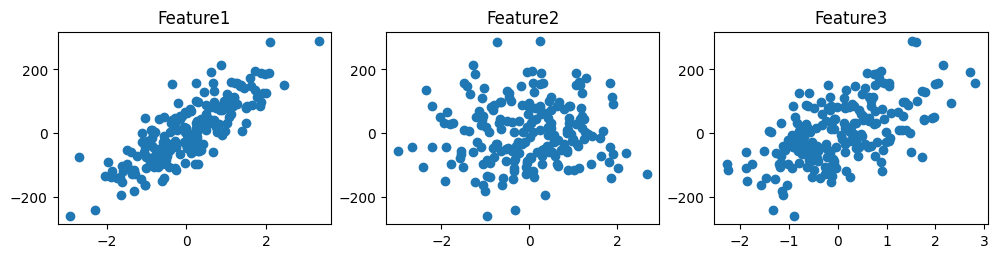

In [8]:
# create three scatter plots to visualize the relationship between each feature and the target
fig, (ax1, ax2, ax3) = plt.subplots(ncols=3, figsize=(12, 2.5))

# plot feature1 against the target
ax1.scatter(df['feature1'], df['target'])
ax1.set_title("Feature1")

# plot feature2 against the target
ax2.scatter(df['feature2'], df['target'])
ax2.set_title("Feature2")

# plot feature3 against the target
ax3.scatter(df['feature3'], df['target'])
ax3.set_title("Feature3")

# display the plots
plt.show()

## **2. Multicollinearity**

In [9]:
# import the function used to calculate variance inflation factor
from statsmodels.stats.outliers_influence import variance_inflation_factor

# create an empty list to store VIF values
vif = []

# calculate VIF for each feature
for i in range(X_train.shape[1]):
    vif.append(variance_inflation_factor(X_train, i))

In [10]:
# create a DataFrame containing the VIF values
# use the feature names as the column names
# transpose the DataFrame for a horizontal view
pd.DataFrame(
    {'vif': vif},
    index=df.columns[0:3]
).T

,feature1,feature2,feature3
vif,1.010326,1.009871,1.01395


<Axes: >

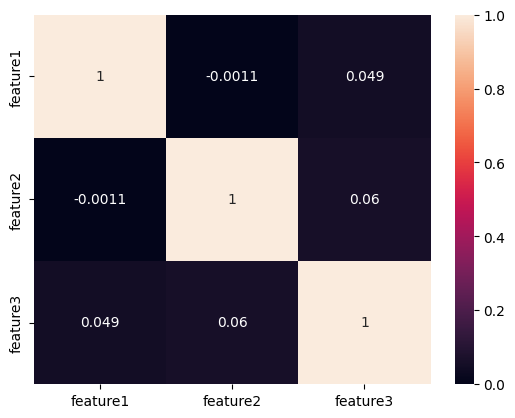

In [11]:
# calculate the correlation between the first three features
# and display the correlation values using a heatmap
sns.heatmap(
    df.iloc[:, 0:3].corr(),
    annot=True
)

## **3. Normality of Residual**

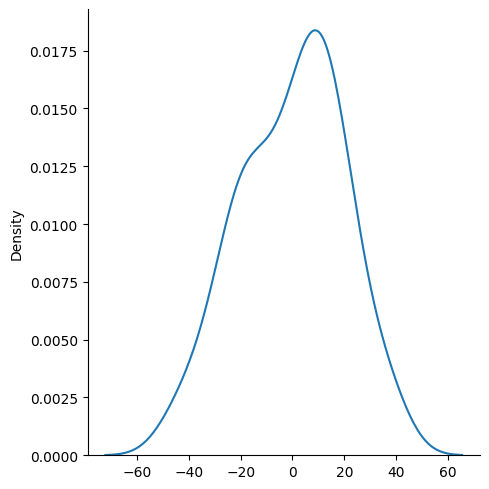

In [12]:
# plot the distribution of residuals using a KDE curve
sns.displot(residual, kind='kde')

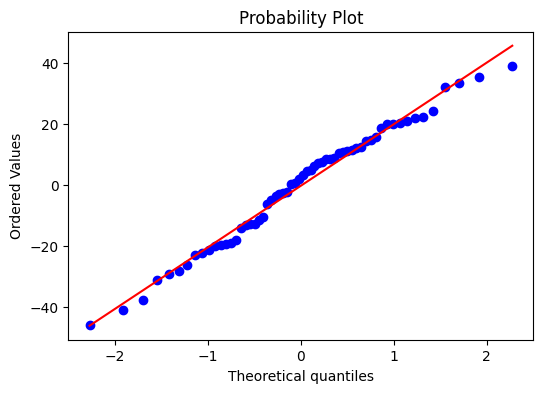

In [13]:
# import scipy for statistical functions
import scipy as sp

# create a figure and axis for the QQ plot
fig, ax = plt.subplots(figsize=(6, 4))

# create a QQ plot to compare residuals with a normal distribution
sp.stats.probplot(residual, plot=ax, fit=True)

# display the QQ plot
plt.show()

## **4. Homoscedasticity**

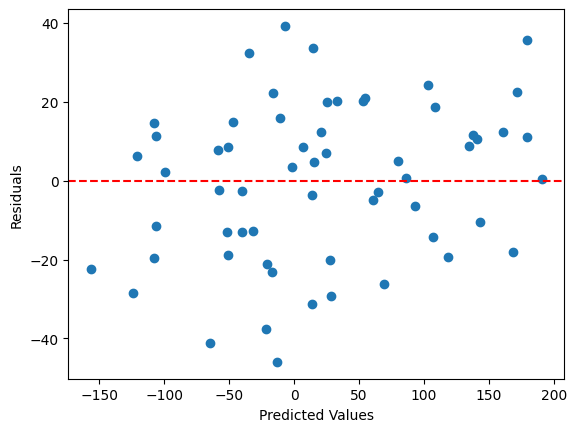

In [14]:
# plot predicted values against residuals
plt.scatter(y_pred, residual)

# add a horizontal reference line at zero
plt.axhline(y=0, color='red', linestyle='--')

# label the axes
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")

# display the plot
plt.show()

## **5. Autocorrelation of Residuals**

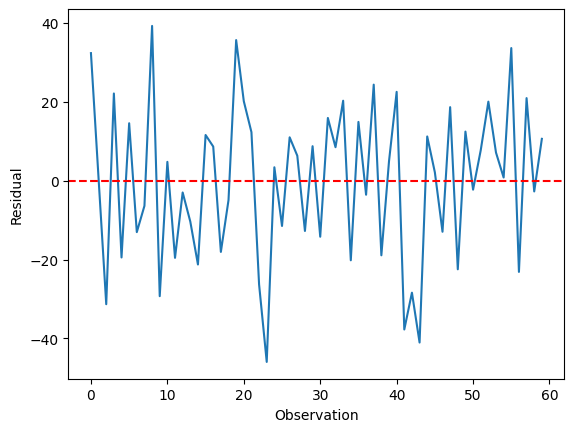

In [15]:
# plot the residuals in the order of the observations
plt.plot(residual)

# add a horizontal reference line at zero
plt.axhline(y=0, color='red', linestyle='--')

# label the axes
plt.xlabel("Observation")
plt.ylabel("Residual")

# display the plot
plt.show()